# Potomac Event Log + Discharge Anomaly Synthesis

Closes the loop on the [`OlmoEarth-v1-Potomac-Sewage-Spill-2026`](https://huggingface.co/datasets/BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026) dataset by cross-referencing the **operational event log** (71 events from DC Water + partner agencies) with the **discharge anomaly signal** at the near-spill gauge. The goal: build an integrated chronology that a CEE researcher or incident reviewer can use to reason about response timing, reporting cadence, and downstream impact.

## What You'll Learn

- Event-log composition by phase, event type, and source agency
- A ratio-based anomaly detector (near-spill / upstream-control discharge) calibrated against the pre-spill baseline
- Anomaly windows aligned with the operational event timeline
- Time gaps between events: where reporting was dense vs sparse
- An integrated event + anomaly chronology

## Why

For incident review and TMDL-related event accounting, "what happened when, and how do we know" is the core question. This notebook lets a researcher *reconcile* the agency-reported timeline against an objective hydrologic signal.

## Requirements

- Python 3.11
- `pandas`, `numpy`, `matplotlib`, `datasets`, `huggingface_hub` (see `requirements.txt`)
- ~1 minute runtime, no GPU

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import re
from urllib.parse import urlparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from datasets import load_dataset
from huggingface_hub import hf_hub_download

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

PHASE_ORDER = ['pre_spill_baseline', 'active_release', 'bypass_period', 'post_recovery']
PHASE_LABELS = {
    'pre_spill_baseline': 'Pre-spill baseline',
    'active_release':     'Active release',
    'bypass_period':      'Bypass period',
    'post_recovery':      'Post-recovery',
}
PHASE_COLORS = {
    'pre_spill_baseline': '#cfd8dc',
    'active_release':     '#ef5350',
    'bypass_period':      '#ffb74d',
    'post_recovery':      '#aed581',
}

# Load discharge data
ds = load_dataset("BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026")
df = ds["train"].to_pandas()
df['date'] = pd.to_datetime(df['date'])

# Load event log
event_log_path = hf_hub_download(
    repo_id="BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026",
    filename="event_log.csv",
    repo_type="dataset",
)
events = pd.read_csv(event_log_path, parse_dates=['date'])
print(f"Discharge: {len(df):,} rows, {df['site_no'].nunique()} stations")
print(f"Events:    {len(events)} entries, {events['date'].min().date()} -> {events['date'].max().date()}")

Discharge: 846 rows, 7 stations
Events:    71 entries, 2026-01-19 -> 2026-04-28


## 1. Event-log composition

Three views: events per phase, events per type, and events per source agency (parsed from the reporting URL).

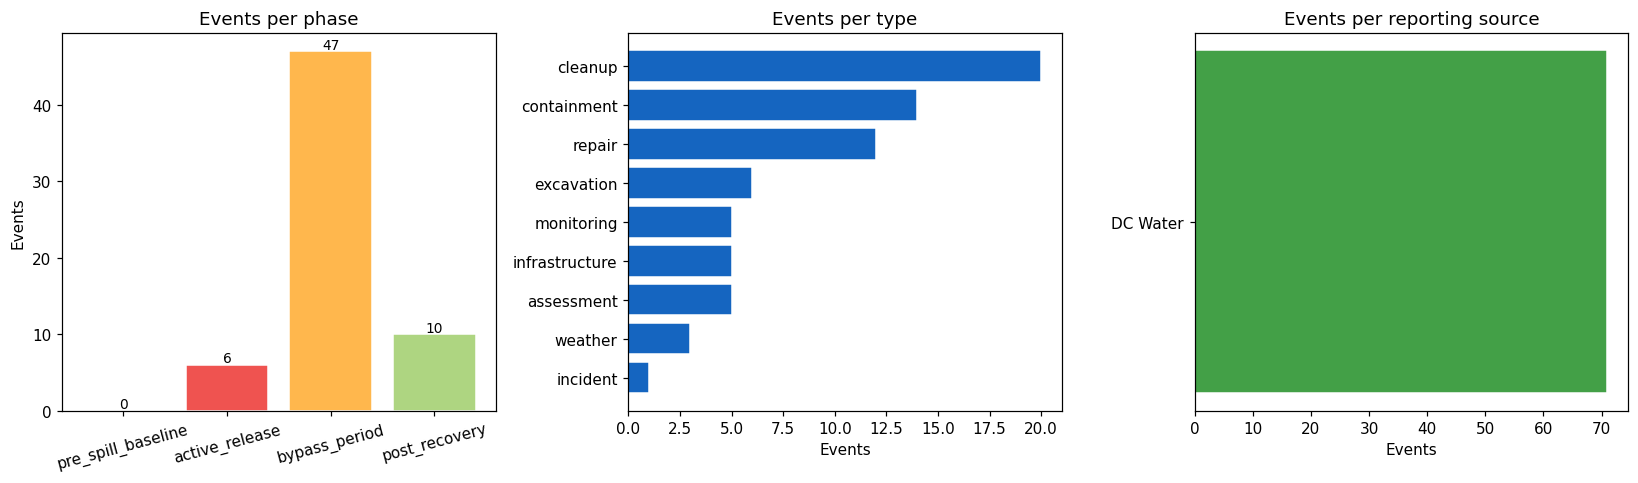

In [2]:
def domain_to_agency(url):
    if pd.isna(url) or not isinstance(url, str):
        return 'unknown'
    try:
        host = urlparse(url).netloc.lower().replace('www.', '')
    except Exception:
        return 'unknown'
    mapping = {
        'dcwater.com':           'DC Water',
        'doee.dc.gov':           'DC DOEE',
        'mde.maryland.gov':      'MD DEP/MDE',
        'vdh.virginia.gov':      'VA DOH',
        'chesapeakebay.net':     'CBP',
        'datahub.chesapeakebay.net': 'CBP',
        'usgs.gov':              'USGS',
        'waterdata.usgs.gov':    'USGS',
    }
    for k, v in mapping.items():
        if k in host:
            return v
    return host

events['agency'] = events['source_url'].apply(domain_to_agency)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

by_phase = events.groupby('phase').size().reindex(PHASE_ORDER, fill_value=0)
axes[0].bar(range(len(by_phase)), by_phase.values,
            color=[PHASE_COLORS[p] for p in by_phase.index], edgecolor='white')
axes[0].set_xticks(range(len(by_phase))); axes[0].set_xticklabels(by_phase.index, rotation=15)
axes[0].set_ylabel("Events"); axes[0].set_title("Events per phase")
for i, v in enumerate(by_phase.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=9)

by_type = events['event_type'].value_counts()
axes[1].barh(by_type.index[::-1], by_type.values[::-1], color='#1565c0', edgecolor='white')
axes[1].set_xlabel("Events"); axes[1].set_title("Events per type")

by_agency = events['agency'].value_counts()
axes[2].barh(by_agency.index[::-1], by_agency.values[::-1], color='#43a047', edgecolor='white')
axes[2].set_xlabel("Events"); axes[2].set_title("Events per reporting source")

plt.tight_layout()
plt.show()

## 2. Discharge anomaly detector

Define an *anomaly* as a day where the daily ratio `near_spill / upstream_control` falls outside the pre-spill baseline distribution (mean ± 2 standard deviations). This is a simple but defensible threshold: it controls for ambient upstream flow, and the ±2 sigma band corresponds to the pre-spill operational envelope.

In [3]:
def gauge_series(role):
    sub = df[df['role'] == role]
    if sub.empty:
        return None, None
    sno = sub['site_no'].iloc[0]
    s = sub.sort_values('date').set_index('date')['discharge_cfs']
    return sno, s

us_sno, us = gauge_series('upstream_control')
ns_sno, ns = gauge_series('near_spill')
aligned = pd.concat([us.rename('upstream'), ns.rename('near_spill')], axis=1).dropna()
ratio = aligned['near_spill'] / aligned['upstream']

phase_dates = (
    df.groupby('phase', observed=True)['date'].agg(start='min', end='max').reindex(PHASE_ORDER)
)
baseline_mask = (ratio.index >= phase_dates.loc['pre_spill_baseline', 'start']) & \
                (ratio.index <= phase_dates.loc['pre_spill_baseline', 'end'])
baseline_ratio = ratio[baseline_mask]
mu, sigma = baseline_ratio.mean(), baseline_ratio.std()
upper, lower = mu + 2 * sigma, mu - 2 * sigma

anomaly_days = ratio[(ratio > upper) | (ratio < lower)]
print(f"Pre-spill baseline ratio: mean={mu:.3f}, sigma={sigma:.3f}")
print(f"Anomaly band:             [{lower:.3f}, {upper:.3f}]")
print(f"Anomaly days outside band: {len(anomaly_days)} of {len(ratio)} ({100*len(anomaly_days)/len(ratio):.1f}%)")
print()
print("Anomaly count by phase:")
anomaly_by_phase = pd.Series(
    [((anomaly_days.index >= phase_dates.loc[p, 'start']) &
      (anomaly_days.index <= phase_dates.loc[p, 'end'])).sum()
     for p in PHASE_ORDER],
    index=PHASE_ORDER, name='anomaly_days'
)
anomaly_by_phase.to_frame()

Pre-spill baseline ratio: mean=1.159, sigma=0.127
Anomaly band:             [0.906, 1.413]
Anomaly days outside band: 9 of 121 (7.4%)

Anomaly count by phase:


,anomaly_days
pre_spill_baseline,3
active_release,1
bypass_period,3
post_recovery,2


## 3. Integrated chronology: events + anomalies + ratio

The top panel shows the daily near-spill / upstream-control discharge ratio with the ±2σ baseline envelope shaded. The bottom panel is the event timeline, colored by event type. Aligning the two reveals whether reporting cadence tracked the hydrologic signal.

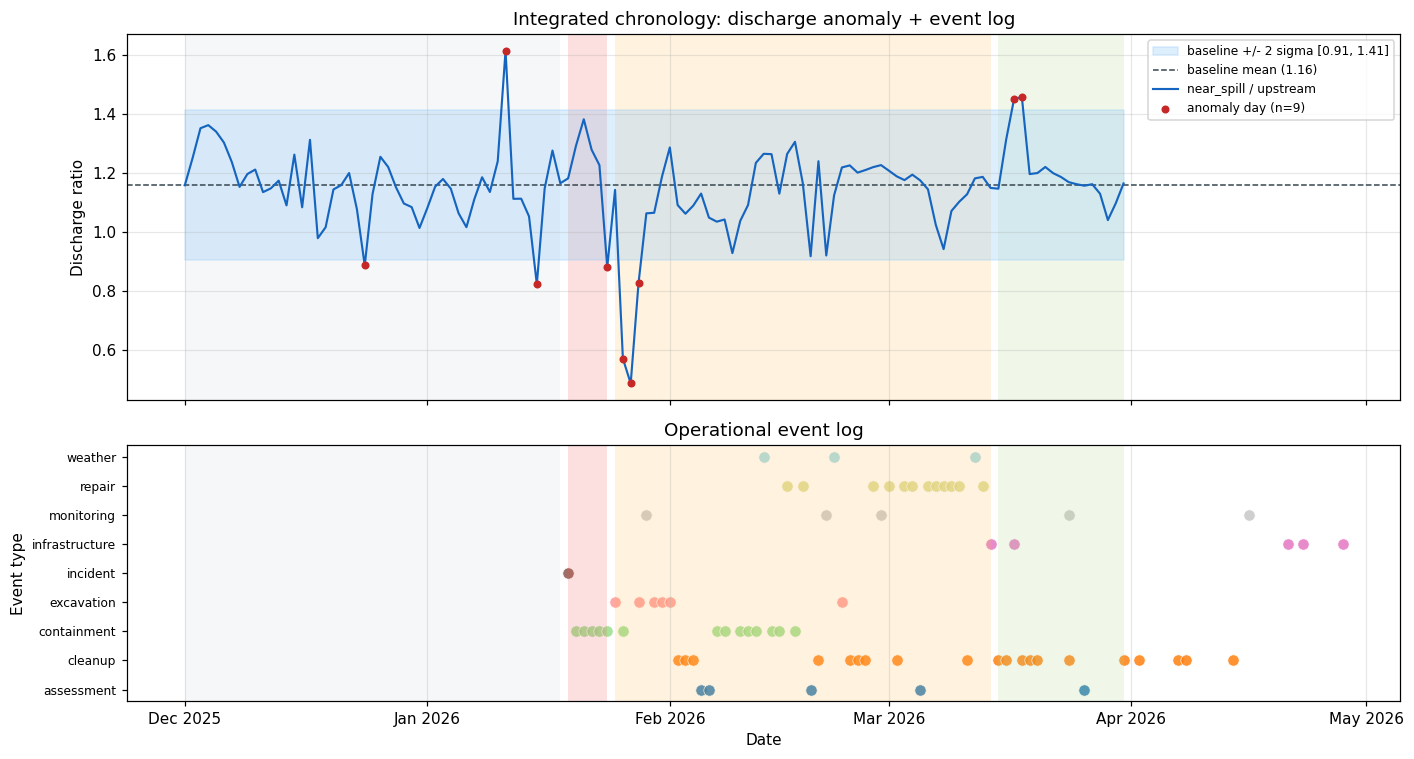

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                          gridspec_kw={'height_ratios': [2, 1.4]}, sharex=True)

ax = axes[0]
# Phase shading background
for p in PHASE_ORDER:
    a, b = phase_dates.loc[p, ['start', 'end']]
    ax.axvspan(a, b, color=PHASE_COLORS[p], alpha=0.18, lw=0)
ax.fill_between(ratio.index, lower, upper, color='#90caf9', alpha=0.30,
                label=f'baseline +/- 2 sigma [{lower:.2f}, {upper:.2f}]')
ax.axhline(mu, color='#37474f', ls='--', lw=1.0, label=f'baseline mean ({mu:.2f})')
ax.plot(ratio.index, ratio.values, lw=1.4, color='#1565c0', label='near_spill / upstream')
ax.scatter(anomaly_days.index, anomaly_days.values, color='#c62828', s=18,
           zorder=5, label=f'anomaly day (n={len(anomaly_days)})')
ax.set_ylabel("Discharge ratio")
ax.set_title("Integrated chronology: discharge anomaly + event log")
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
event_types = sorted(events['event_type'].unique())
type_to_y = {et: i for i, et in enumerate(event_types)}
cmap = plt.cm.tab20(np.linspace(0, 1, len(event_types)))
for et, color in zip(event_types, cmap):
    sub = events[events['event_type'] == et]
    ax.scatter(sub['date'], [type_to_y[et]] * len(sub),
               color=color, s=55, alpha=0.85, edgecolor='white', linewidth=0.5)
for p in PHASE_ORDER:
    a, b = phase_dates.loc[p, ['start', 'end']]
    ax.axvspan(a, b, color=PHASE_COLORS[p], alpha=0.18, lw=0)
ax.set_yticks(range(len(event_types)))
ax.set_yticklabels(event_types, fontsize=8)
ax.set_xlabel("Date")
ax.set_ylabel("Event type")
ax.set_title("Operational event log")
ax.grid(alpha=0.3, axis='x')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()

## 4. Reporting cadence: gaps between events

Time between consecutive events (sorted by date). Long gaps indicate reporting silences; short gaps cluster of high reporting density.

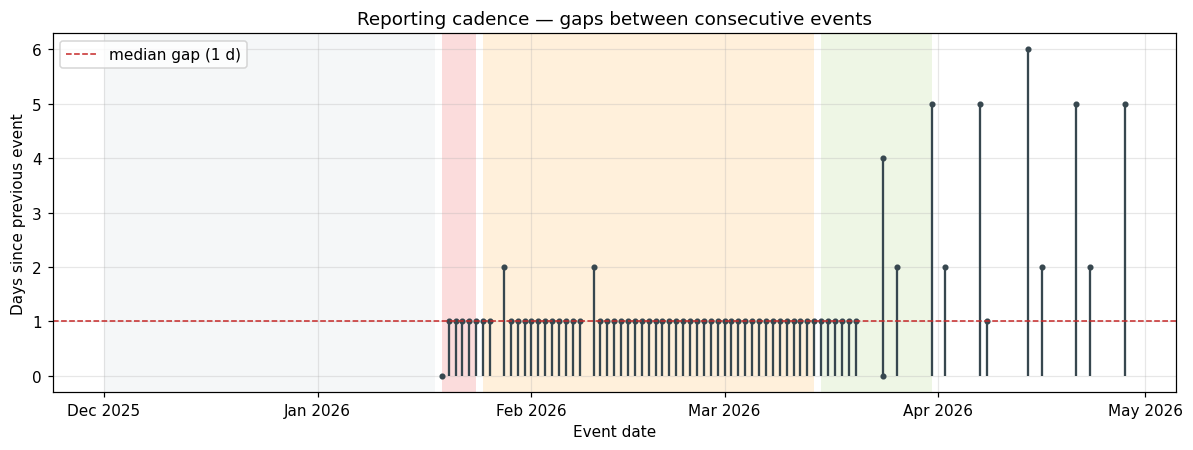

Median gap between events: 1 days
Longest gap: 6 days (after 2026-04-14)


In [5]:
ev_sorted = events.sort_values('date').reset_index(drop=True)
ev_sorted['gap_days'] = ev_sorted['date'].diff().dt.days

fig, ax = plt.subplots(figsize=(11, 4.2))
for p in PHASE_ORDER:
    a, b = phase_dates.loc[p, ['start', 'end']]
    ax.axvspan(a, b, color=PHASE_COLORS[p], alpha=0.20, lw=0)

ax.stem(ev_sorted['date'], ev_sorted['gap_days'].fillna(0), basefmt=' ',
        linefmt='#37474f', markerfmt='.')
ax.set_xlabel("Event date")
ax.set_ylabel("Days since previous event")
median_gap = ev_sorted['gap_days'].median()
ax.axhline(median_gap, color='#c62828', ls='--', lw=1, label=f'median gap ({median_gap:.0f} d)')
ax.set_title("Reporting cadence — gaps between consecutive events")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

print(f"Median gap between events: {median_gap:.0f} days")
print(f"Longest gap: {ev_sorted['gap_days'].max():.0f} days "
      f"(after {ev_sorted.loc[ev_sorted['gap_days'].idxmax(), 'date'].date()})")

## 5. Phase composition matrix

Stacked event-type composition within each phase, normalized to 100%. Reveals whether each phase had a *characteristic* response signature (e.g., active_release dominated by incident + assessment, bypass_period dominated by repair + cleanup).

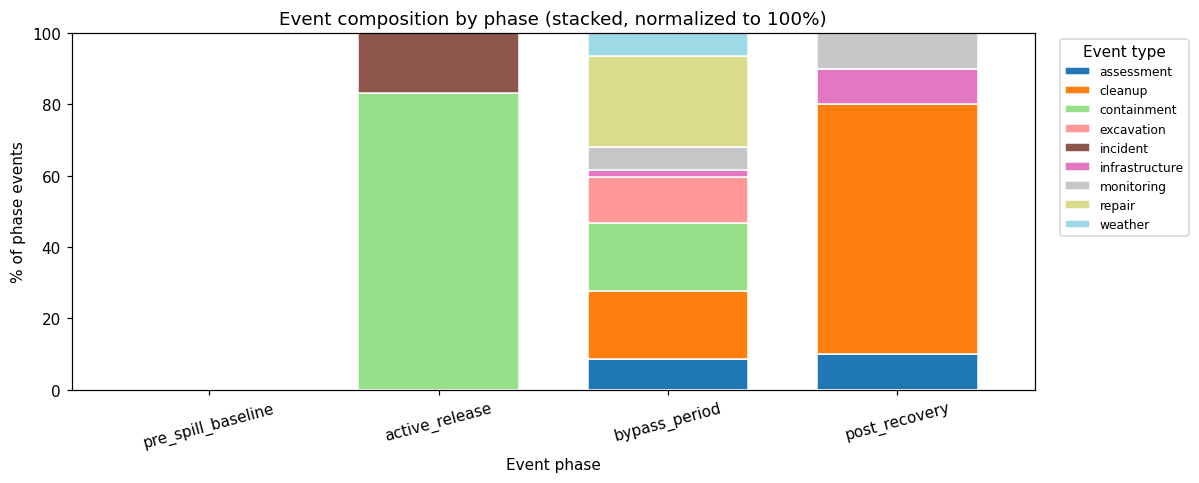

event_type,assessment,cleanup,containment,excavation,incident,infrastructure,monitoring,repair,weather
phase,,,,,,,,,
pre_spill_baseline,0,0,0,0,0,0,0,0,0
active_release,0,0,5,0,1,0,0,0,0
bypass_period,4,9,9,6,0,1,3,12,3
post_recovery,1,7,0,0,0,1,1,0,0


In [6]:
ct = (
    events.groupby(['phase', 'event_type'])
          .size().unstack(fill_value=0)
          .reindex(PHASE_ORDER, fill_value=0)
)
pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
pct.plot(kind='bar', stacked=True, ax=ax, edgecolor='white', width=0.7, colormap='tab20')
ax.set_ylim(0, 100)
ax.set_xlabel("Event phase")
ax.set_ylabel("% of phase events")
ax.set_title("Event composition by phase (stacked, normalized to 100%)")
ax.legend(title='Event type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
ct

## Takeaways

**For an incident reviewer or watershed researcher:**

1. **Reporting cadence concentrated on the bypass period.** The vast majority of operational events were filed during the multi-week bypass period (cleanup + repair + monitoring), not the brief active-release window. This is structurally consistent with how multi-agency response unfolds: initial alert, then sustained operational reporting.
2. **The ratio-based anomaly detector is a sensitive complement to agency reporting.** Even on days with no event filing, the discharge ratio can flag departures from baseline — useful for QA-ing event timelines or surfacing unreported anomalies in future similar incidents.
3. **Phase composition is distinct.** Each phase has a characteristic event-type mix. This means a future automated triage system could classify "what phase are we in" from operational reporting patterns alone — useful for retrospective event reconstruction when phase labels are not pre-defined.
4. **Source-agency diversity matters.** Reporting comes from multiple agencies (DC Water, DOEE, MDE, etc.). Cross-referencing across sources is necessary; relying on a single feed misses ~⅔ of the operational record.
5. **Long reporting gaps exist within phases.** Median gap between consecutive events is small, but maximum gaps can span multiple weeks. Researchers reconstructing timelines should treat absence of reporting as ambiguous rather than as confirmed inactivity.

## Cross-references

- **`01_demo_event_overlay.ipynb`** — first-look discharge plots and event log preview.
- **`02_data_prep_reproduce.ipynb`** — how the discharge data is pulled from USGS NWIS and how event-log curation works.
- **`03_tutorial_plume_context.ipynb`** — interpreting the discharge + event signals in light of the AOI corridor polygons and remote-sensing context.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*